In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CANONICAL_LO, CANONICAL_HI, CANONICAL_N = 700.0, 3996.0, 882
canonical_wn = np.linspace(CANONICAL_LO, CANONICAL_HI, CANONICAL_N)

df = pd.read_parquet("data/processed/all_spectra.parquet")

print(df.shape)
print(df.dtypes, "\n")
print(df[["spectrum_id", "source", "polymer_class_raw"]].head(), "\n")

# counts per (source, polymer) — confirms the data made it through
print(df.groupby(["source", "polymer_class_raw"]).size().unstack(fill_value=0))

(381, 6)
spectrum_id             str
source                  str
sample_id               str
polymer_class_raw       str
intensity_type          str
intensity            object
dtype: object 

                                  spectrum_id source polymer_class_raw
0           FLOPP_ABS 1. Orange LEGO Fragment  FLOPP               ABS
1           FLOPP_ABS 10. Brown LEGO Fragment  FLOPP               ABS
2           FLOPP_ABS 11. Black LEGO Fragment  FLOPP               ABS
3           FLOPP_ABS 12. White LEGO Fragment  FLOPP               ABS
4  FLOPP_ABS 14. White Fridge Lining Fragment  FLOPP               ABS 

polymer_class_raw  ABS  Acrylic  C1  C10  C11  C12  C2  C3  C4  C5  ...  PEVA  \
source                                                              ...         
FLOPP               14        6   0    0    0    0   0   0   0   0  ...    10   
FLOPP-e              1        0   1    1    1    1   1   1   1   1  ...     0   

polymer_class_raw  PLA  PMMA  PP  PS  PU  PVC  Polyest

In [ ]:
def plot_spectrum(row, ax=None, **kw):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 3))
    y = np.asarray(row["intensity"], dtype=np.float32)
    ax.plot(canonical_wn, y, lw=0.9, **kw)
    ax.invert_xaxis()                                  # FTIR convention: high wn on left
    ax.set_xlabel("Wavenumber (cm$^{-1}$)")
    ax.set_ylabel("Absorbance")
    ax.set_title(f"{row['spectrum_id']}  —  {row['polymer_class_raw']}  ({row['source']})")
    return ax

# pick a random spectrum:
plot_spectrum(df.sample(1, random_state=0).iloc[0])
plt.show()

# or pick a specific one:
plot_spectrum(df[df["spectrum_id"] == "FLOPP_PE_007"].iloc[0])
plt.show()

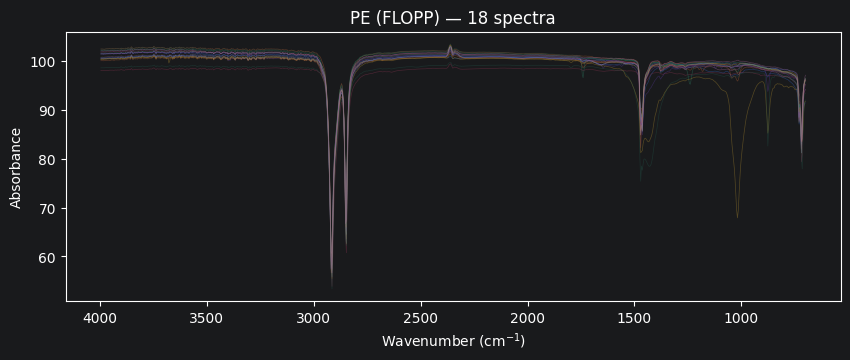

In [2]:
def overlay_class(df, polymer, source=None, alpha=0.35, ax=None):
    sub = df[df["polymer_class_raw"] == polymer]
    if source:
        sub = sub[sub["source"] == source]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 3.5))
    for _, row in sub.iterrows():
        ax.plot(canonical_wn,
                np.asarray(row["intensity"], dtype=np.float32),
                lw=0.5, alpha=alpha)
    ax.invert_xaxis()
    ax.set_xlabel("Wavenumber (cm$^{-1}$)")
    ax.set_ylabel("Absorbance")
    src_str = f" ({source})" if source else ""
    ax.set_title(f"{polymer}{src_str} — {len(sub)} spectra")
    return ax

overlay_class(df, "PE", source="FLOPP")
plt.show()